# Deputado federal no Amazonas: 2022 e 2026

Mesma leitura do notebook nacional, restrita à circunscrição do **Amazonas** (`UF = AM`). Deputado federal é eleito por estado, então entram só candidaturas e deputados com UF Amazonas.

As candidaturas exibidas são as **aptas** na eleição ordinária.

O arquivo de candidatos de 2022 já pode estar em `dados/brutos/`. Votos e prestação de contas continuam vindo dos ZIPs oficiais do TSE; se o download for recusado, salve o arquivo no caminho indicado pela mensagem de erro e execute a célula de novo.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().resolve()
if not (RAIZ / "eleitoral").exists() and (RAIZ.parent / "eleitoral").exists():
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from eleitoral.analise import (
    comparar_disputas,
    cruzar_deputados,
    grafico_barras,
    resumo_por_partido,
    tabela_reais,
)
from eleitoral.camara import carregar_deputados_atuais
from eleitoral.config import DATA_CORTE_2026
from eleitoral.regras import formatar_inteiro
from eleitoral.tse import (
    carregar_candidatos,
    carregar_gastos_publicidade,
    carregar_votos,
    colunas_para_exibir,
)

UF = "AM"
COLUNAS_CANDIDATO = ["partido", "numero", "nome_urna", "nome", "situacao", "resultado", "federacao"]

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 48)

print("Projeto:", RAIZ)
print("Recorte: Amazonas (" + UF + ")")
print("Corte da publicidade de 2026:", DATA_CORTE_2026.strftime("%d/%m/%Y"))

Projeto: C:\Users\Luiz\Documents\analise-eleitoral
Recorte: Amazonas (AM)
Corte da publicidade de 2026: 28/09/2026


## Candidatos a deputado federal em 2022 no Amazonas, por partido

Arquivo local: consulta_cand_2022.zip
Lendo tabela já processada: candidatos_deputado_federal_2022_aptos_AM.csv
149 candidaturas aptas a deputado federal no Amazonas em 2022


,partido,candidatos
0,AVANTE,9
1,MDB,9
2,PATRIOTA,9
3,PDT,9
4,PL,9
5,PMN,9
6,PSC,9
7,PSD,9
8,REPUBLICANOS,9
9,UNIÃO,9


,partido,numero,nome_urna,nome,situacao,resultado,federacao
0,AGIR,3636,DANIEL OLIVEIRA,MARCOS OLIVEIRA GAZEL,APTO,NÃO ELEITO,#NULO
1,AGIR,3600,EDINHO,EDSON DO NASCIMENTO PEREIRA,APTO,NÃO ELEITO,#NULO
2,AGIR,3655,ERIVELTO SILVA,ANTÔNIO ERIVELTON FERNANDES DA SILVA,APTO,NÃO ELEITO,#NULO
3,AGIR,3672,FÁTIMA SPENER,FÁTIMA VITÓRIA DE JESUS SPENER XAVIER,APTO,NÃO ELEITO,#NULO
4,AGIR,3633,IRMÃO RIBEIRO,GILMAR DA SILVA RIBEIRO,APTO,NÃO ELEITO,#NULO
5,AGIR,3612,JONIA MUNIZ,JONIA MUNIZ DA SILVA,APTO,NÃO ELEITO,#NULO
6,AGIR,3622,SILVIO MAIA,SILVIO JOSÉ CINTRA MAIA,APTO,NÃO ELEITO,#NULO
7,AVANTE,7007,CRIS PAIVA,CRISTINA LÚCIA FERREIRA PAIVA,APTO,NÃO ELEITO,#NULO
8,AVANTE,7070,DAVID REIS,DAVID VALENTE REIS,APTO,NÃO ELEITO,#NULO
9,AVANTE,7044,HISSA ABRAHÃO,HISSA NAGIB ABRAHÃO FILHO,APTO,NÃO ELEITO,#NULO


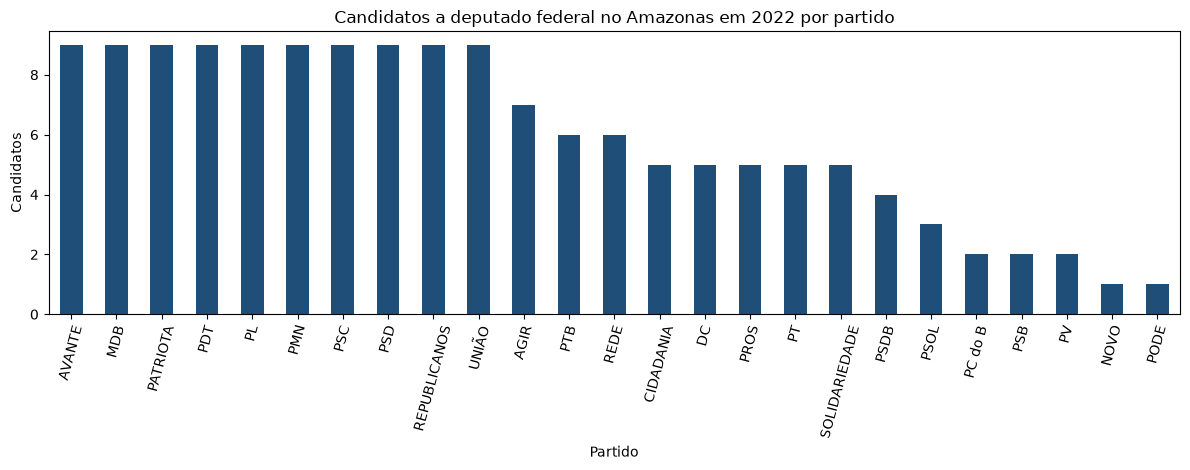

In [2]:
candidatos_2022 = carregar_candidatos(2022, uf=UF)
print(f"{formatar_inteiro(len(candidatos_2022))} candidaturas aptas a deputado federal no Amazonas em 2022")
resumo_2022 = resumo_por_partido(candidatos_2022)
display(resumo_2022)
grafico_barras(
    resumo_2022,
    "Candidatos a deputado federal no Amazonas em 2022 por partido",
    "candidatos",
    "Candidatos",
)
display(colunas_para_exibir(candidatos_2022, COLUNAS_CANDIDATO))

## Deputados federais do Amazonas em exercício, por partido

Lista da Câmara para a UF Amazonas, com o partido atual e suplentes em exercício.

Lendo tabela já processada: deputados_atuais_AM.csv
8 deputados do Amazonas em exercício


,partido,deputados
0,MDB,2
1,PSD,2
2,REPUBLICANOS,2
3,PL,1
4,UNIÃO,1


,partido,nome,nome_eleitoral,situacao
0,MDB,Adail Filho,Adail Filho,Exercício
1,MDB,Saullo Vianna,Saullo Vianna,Exercício
2,PL,Capitão Alberto Neto,Capitão Alberto Neto,Exercício
3,PSD,Sidney Leite,Sidney Leite,Exercício
4,PSD,Átila Lins,Átila Lins,Exercício
5,REPUBLICANOS,Amom Mandel,Amom Mandel,Exercício
6,REPUBLICANOS,Silas Câmara,Silas Câmara,Exercício
7,UNIÃO,Fausto Jr.,Fausto Jr.,Exercício


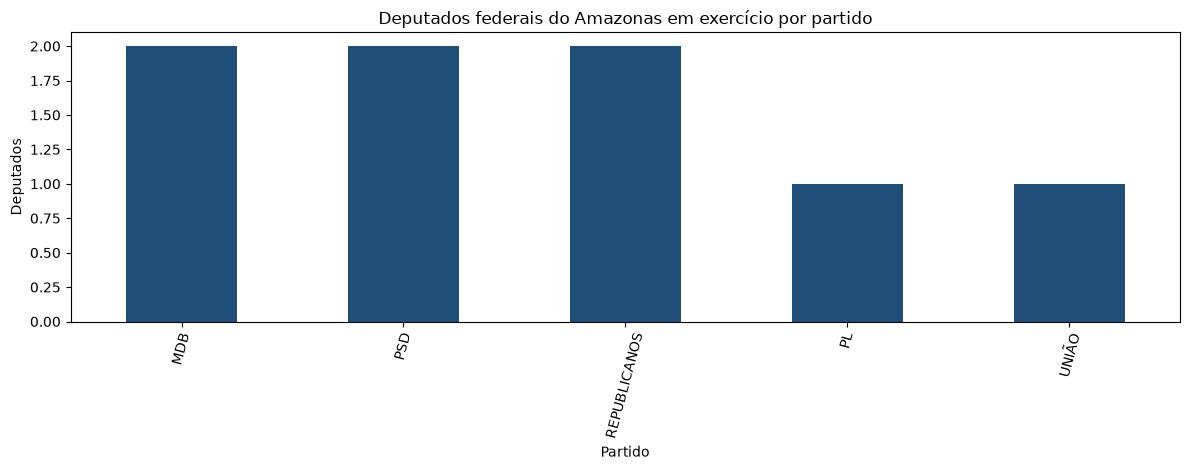

In [3]:
deputados_atuais = carregar_deputados_atuais(uf=UF)
print(f"{formatar_inteiro(len(deputados_atuais))} deputados do Amazonas em exercício")
resumo_deputados = resumo_por_partido(deputados_atuais, nome_contagem="deputados")
display(resumo_deputados)
grafico_barras(
    resumo_deputados,
    "Deputados federais do Amazonas em exercício por partido",
    "deputados",
    "Deputados",
)
display(deputados_atuais[["partido", "nome", "nome_eleitoral", "situacao"]])

## Candidatos a deputado federal em 2026 no Amazonas, por partido

Arquivo local: consulta_cand_2026.zip
Lendo tabela já processada: candidatos_deputado_federal_2026_aptos_AM.csv
139 candidaturas aptas a deputado federal no Amazonas em 2026


,partido,candidatos
0,AVANTE,9
1,DC,9
2,MDB,9
3,MISSÃO,9
4,NOVO,9
5,PL,9
6,PODE,9
7,PSB,9
8,PSD,9
9,REPUBLICANOS,9


,partido,numero,nome_urna,nome,federacao
0,AVANTE,7022,CORONEL MENEZES,ALFREDO ALEXANDRE DE MENEZES JUNIOR,#NULO
1,AVANTE,7007,CRIS PAIVA,CRISTINA LUCIA FERREIRA PAIVA,#NULO
2,AVANTE,7010,DR RAIONE CABRAL,RAIONE CABRAL QUEIROZ,#NULO
3,AVANTE,7070,DRA ARYEL ALMEIDA,FERNANDA ARYEL RODRIGUES DE ALMEIDA LIMA,#NULO
4,AVANTE,7077,DRA. EUNICE NASCIMENTO,MARIA EUNICE TORRES DO NASCIMENTO,#NULO
5,AVANTE,7001,JOELSON SILVA,JOELSON SALES SILVA,#NULO
6,AVANTE,7000,JUNIOR RESGATE,GILBERTO BORGES DOS SANTOS JUNIOR,#NULO
7,AVANTE,7012,PROFESSOR DALMIR SALAZAR,ANTONIO DALMIR BEZERRA SALAZAR,#NULO
8,AVANTE,7025,RADYR JUNIOR,RADYR GOMES DE OLIVEIRA JUNIOR,#NULO
9,DC,2777,DENISON VILAR DA SAÚDE,DENISON DE CARVALHO VILAR,#NULO


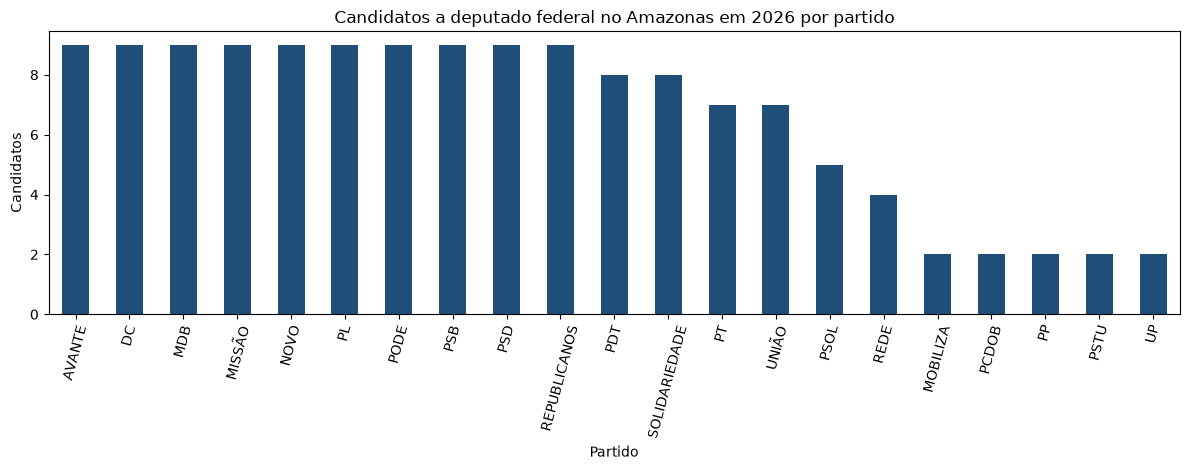

In [4]:
candidatos_2026 = carregar_candidatos(2026, uf=UF)
print(f"{formatar_inteiro(len(candidatos_2026))} candidaturas aptas a deputado federal no Amazonas em 2026")
resumo_2026 = resumo_por_partido(candidatos_2026)
display(resumo_2026)
grafico_barras(
    resumo_2026,
    "Candidatos a deputado federal no Amazonas em 2026 por partido",
    "candidatos",
    "Candidatos",
)
display(colunas_para_exibir(candidatos_2026, COLUNAS_CANDIDATO))

## Quem saiu e quem entrou no Amazonas

A comparação usa só as candidaturas aptas do estado.

- **Saiu:** disputou o Amazonas em 2022 e não disputa em 2026.
- **Entrou:** disputa o Amazonas em 2026 e não disputou em 2022.
- **Continua:** está nas duas. Troca de partido aparece na tabela seguinte.

Depois vêm os eleitos de 2022 no Amazonas que não concorrem em 2026 e os deputados do estado em exercício que não estão na disputa de 2026.

In [5]:
comparacao = comparar_disputas(candidatos_2022, candidatos_2026)
print(f"Saíram: {formatar_inteiro(len(comparacao.sairam))}")
print(f"Entraram: {formatar_inteiro(len(comparacao.entraram))}")
print(f"Continuam: {formatar_inteiro(len(comparacao.continuam))}")
print(f"Trocaram de partido: {formatar_inteiro(len(comparacao.mudaram_de_partido))}")
print(f"Eleitos em 2022 no Amazonas que não concorrem em 2026: {formatar_inteiro(len(comparacao.eleitos_que_nao_concorrem))}")

display(comparacao.resumo_sairam)
display(colunas_para_exibir(comparacao.sairam, COLUNAS_CANDIDATO))
display(comparacao.resumo_entraram)
display(colunas_para_exibir(comparacao.entraram, COLUNAS_CANDIDATO))
display(comparacao.mudaram_de_partido[["nome_urna", "nome", "partido_2022", "partido_2026"]])
display(colunas_para_exibir(comparacao.eleitos_que_nao_concorrem, COLUNAS_CANDIDATO))

mandato = cruzar_deputados(deputados_atuais, candidatos_2026)
print(f"Deputados do Amazonas em exercício fora da disputa de 2026: {formatar_inteiro(len(mandato.fora_da_disputa_2026))}")
print(f"Deputados do Amazonas em exercício na disputa de 2026: {formatar_inteiro(len(mandato.na_disputa_2026))}")
display(mandato.resumo_fora)
display(mandato.fora_da_disputa_2026[["partido", "nome", "nome_eleitoral"]])

Saíram: 126
Entraram: 116
Continuam: 23
Trocaram de partido: 9
Eleitos em 2022 no Amazonas que não concorrem em 2026: 1


,partido,candidatos
0,PATRIOTA,9
1,PDT,9
2,PMN,9
3,PSC,9
4,AGIR,7
5,AVANTE,7
6,MDB,7
7,PL,7
8,PSD,6
9,PTB,6


,partido,numero,nome_urna,nome,situacao,resultado,federacao
0,AGIR,3636,DANIEL OLIVEIRA,MARCOS OLIVEIRA GAZEL,APTO,NÃO ELEITO,#NULO
1,AGIR,3600,EDINHO,EDSON DO NASCIMENTO PEREIRA,APTO,NÃO ELEITO,#NULO
2,AGIR,3655,ERIVELTO SILVA,ANTÔNIO ERIVELTON FERNANDES DA SILVA,APTO,NÃO ELEITO,#NULO
3,AGIR,3672,FÁTIMA SPENER,FÁTIMA VITÓRIA DE JESUS SPENER XAVIER,APTO,NÃO ELEITO,#NULO
4,AGIR,3633,IRMÃO RIBEIRO,GILMAR DA SILVA RIBEIRO,APTO,NÃO ELEITO,#NULO
5,AGIR,3612,JONIA MUNIZ,JONIA MUNIZ DA SILVA,APTO,NÃO ELEITO,#NULO
6,AGIR,3622,SILVIO MAIA,SILVIO JOSÉ CINTRA MAIA,APTO,NÃO ELEITO,#NULO
7,AVANTE,7070,DAVID REIS,DAVID VALENTE REIS,APTO,NÃO ELEITO,#NULO
8,AVANTE,7010,KATY FEITOZA,KATIANE GAMA FEITOZA,APTO,NÃO ELEITO,#NULO
9,AVANTE,7001,LILIANE ARAÚJO,LILIANE ARAUJO DE ALMEIDA,APTO,NÃO ELEITO,#NULO


,partido,candidatos
0,DC,9
1,MISSÃO,9
2,NOVO,9
3,PSB,9
4,AVANTE,8
5,PDT,8
6,PODE,8
7,SOLIDARIEDADE,7
8,MDB,6
9,PL,6


,partido,numero,nome_urna,nome,federacao
0,AVANTE,7022,CORONEL MENEZES,ALFREDO ALEXANDRE DE MENEZES JUNIOR,#NULO
1,AVANTE,7010,DR RAIONE CABRAL,RAIONE CABRAL QUEIROZ,#NULO
2,AVANTE,7070,DRA ARYEL ALMEIDA,FERNANDA ARYEL RODRIGUES DE ALMEIDA LIMA,#NULO
3,AVANTE,7077,DRA. EUNICE NASCIMENTO,MARIA EUNICE TORRES DO NASCIMENTO,#NULO
4,AVANTE,7001,JOELSON SILVA,JOELSON SALES SILVA,#NULO
5,AVANTE,7000,JUNIOR RESGATE,GILBERTO BORGES DOS SANTOS JUNIOR,#NULO
6,AVANTE,7012,PROFESSOR DALMIR SALAZAR,ANTONIO DALMIR BEZERRA SALAZAR,#NULO
7,AVANTE,7025,RADYR JUNIOR,RADYR GOMES DE OLIVEIRA JUNIOR,#NULO
8,DC,2777,DENISON VILAR DA SAÚDE,DENISON DE CARVALHO VILAR,#NULO
9,DC,2766,DOUTORA AMANDA SOUZA,AMANDA TEREZA NASCIMENTO DE SOUZA,#NULO


,nome_urna,nome,partido_2022,partido_2026
0,HISSA ABRAHÃO,HISSA NAGIB ABRAHÃO FILHO,AVANTE,REPUBLICANOS
1,AMOM MANDEL,AMOM MANDEL LINS FILHO,CIDADANIA,REPUBLICANOS
2,SARGENTO AUGUSTO,CÉSAR AUGUSTO OLIVEIRA DA FONSECA,MDB,PODE
3,VIVIANE LIMA,VIVIANE PEREIRA DA SILVA LAGO LIMA,MDB,REPUBLICANOS
4,VANDA WITOTO,VANDERLECIA ORTEGA DOS SANTOS,REDE,MDB
5,ADAIL FILHO,ADAIL JOSÉ FIGUEIREDO PINHEIRO,REPUBLICANOS,MDB
6,DELEGADO PABLO,PABLO OLIVA SOUZA,UNIÃO,PL
7,PAUDERNEY AVELINO,PAUDERNEY TOMAZ AVELINO,UNIÃO,PSD
8,SAULLO VIANNA,SAULLO VELAME VIANNA,UNIÃO,MDB


,partido,numero,nome_urna,nome,situacao,resultado
0,PL,2210,CAPITÃO ALBERTO NETO,ALBERTO BARROS CAVALCANTE NETO,APTO,ELEITO POR MÉDIA


Deputados do Amazonas em exercício fora da disputa de 2026: 1
Deputados do Amazonas em exercício na disputa de 2026: 7


,partido,deputados
0,PL,1


,partido,nome,nome_eleitoral
0,PL,Capitão Alberto Neto,Capitão Alberto Neto


## Votos de 2022 por candidato no Amazonas

Soma dos votos nominais do 1º turno na circunscrição do estado.

O TSE recusou o download. Usando a cópia pública do Internet Archive.
Baixando votacao_candidato_munzona_2022.zip: 100%
Download concluído: votacao_candidato_munzona_2022.zip (749.1 MB)
Lendo votacao_candidato_munzona_2022_AM.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\votos_deputado_federal_2022_AM.csv
Total de votos nominais no Amazonas: 1.930.224


,partido,candidatos,votos
0,UNIÃO,9,363768
1,PSD,9,327445
2,CIDADANIA,5,311831
3,REPUBLICANOS,9,289647
4,PL,9,227086
5,AVANTE,9,137099
6,PT,5,108788
7,PC do B,2,36879
8,MDB,9,35390
9,REDE,6,27951


,partido,numero,nome_urna,nome,resultado,votos
0,CIDADANIA,2323,AMOM MANDEL,AMOM MANDEL LINS FILHO,ELEITO POR QP,288555
1,PL,2210,CAPITÃO ALBERTO NETO,ALBERTO BARROS CAVALCANTE NETO,ELEITO POR MÉDIA,147846
2,UNIÃO,4455,SAULLO VIANNA,SAULLO VELAME VIANNA,ELEITO POR QP,127287
3,REPUBLICANOS,1010,SILAS CÂMARA,SILAS CÂMARA,ELEITO POR QP,125068
4,PSD,5525,ATILA LINS,ATILA SIDNEY LINS DE ALBUQUERQUE,ELEITO POR QP,102401
5,PSD,5555,SIDNEY LEITE,SIDNEY RICARDO DE OLIVEIRA LEITE,ELEITO POR MÉDIA,102181
6,REPUBLICANOS,1000,ADAIL FILHO,ADAIL JOSÉ FIGUEIREDO PINHEIRO,ELEITO POR MÉDIA,90028
7,PT,1313,ZÉ RICARDO,JOSÉ RICARDO WENDLING,NÃO ELEITO,89017
8,UNIÃO,4477,FAUSTO SANTOS JR,FAUSTO VIEIRA DOS SANTOS JÚNIOR,ELEITO POR MÉDIA,87876
9,PSD,5500,MARCELO RAMOS,MARCELO RAMOS RODRIGUES,SUPLENTE,74387


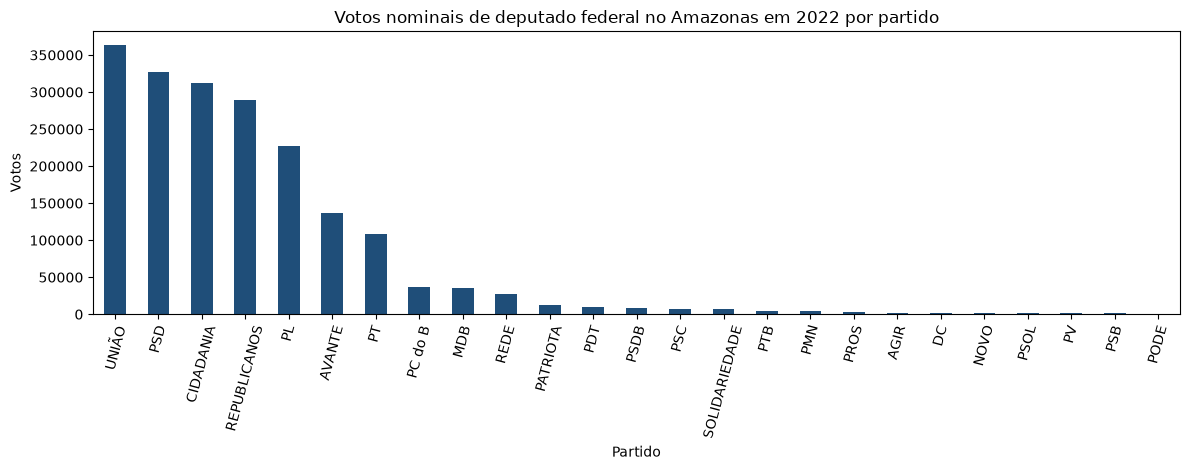

In [6]:
votos_2022 = carregar_votos(candidatos_2022, uf=UF)
print(f"Total de votos nominais no Amazonas: {formatar_inteiro(votos_2022['votos'].sum())}")
resumo_votos = resumo_por_partido(votos_2022, valor="votos")
display(resumo_votos)
grafico_barras(
    resumo_votos,
    "Votos nominais de deputado federal no Amazonas em 2022 por partido",
    "votos",
    "Votos",
)
display(colunas_para_exibir(votos_2022, ["partido", "numero", "nome_urna", "nome", "resultado", "votos"]))

## Gasto com publicidade em 2022 no Amazonas, por candidato

Soma das despesas contratadas de publicidade, propaganda, impulsionamento ou páginas na internet dos candidatos do estado. Candidato com R$ 0,00 não declarou despesa contratada nesses tipos.

O TSE recusou o download. Usando a cópia pública do Internet Archive.
Baixando prestacao_contas_candidatos_2022.zip: 100%
Download concluído: prestacao_contas_candidatos_2022.zip (132.2 MB)
Lendo despesas_contratadas_candidatos_2022_AM.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\publicidade_deputado_federal_2022_AM_completa.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\publicidade_categorias_2022_AM_completa.csv
Deputado federal 2022: despesas contratadas de publicidade, prestação final do pleito. Recorte: AM. Arquivo do TSE gerado em 15/09/2022. Período com despesa datada: 02/08/2022 a 24/09/2022. Lançamentos de publicidade somados: 842. Lançamentos depois do corte: 0. Lançamentos sem data: 0. Coluna de classificação: DS_ORIGEM_DESPESA. Total: R$ 8.617.098,05.


,tipo,lancamentos,valor,entra_na_publicidade
0,Atividades de militância e mobilização de rua,7604,"R$ 6.570.025,48",não
1,Publicidade por materiais impressos,452,"R$ 5.452.611,00",sim
2,Publicidade por adesivos,209,"R$ 2.082.726,80",sim
3,Despesas com transporte ou deslocamento,43,"R$ 2.013.391,34",não
4,"Produção de programas de rádio, televisão ou...",16,"R$ 1.464.736,36",não
5,Cessão ou locação de veículos,292,"R$ 1.387.368,56",não
6,Despesas com pessoal,1277,"R$ 1.338.873,02",não
7,Serviços advocatícios,58,"R$ 1.279.504,80",não
8,Serviços prestados por terceiros,553,"R$ 1.113.918,27",não
9,Diversas a especificar,130,"R$ 1.002.656,69",não


,partido,candidatos,gasto_publicidade
0,UNIÃO,9,"R$ 1.936.782,43"
1,PSD,9,"R$ 1.765.807,50"
2,REPUBLICANOS,9,"R$ 1.307.805,00"
3,PL,9,"R$ 927.436,00"
4,MDB,9,"R$ 728.589,00"
5,PT,5,"R$ 710.397,12"
6,PROS,5,"R$ 503.250,00"
7,AVANTE,9,"R$ 281.990,00"
8,PC do B,2,"R$ 136.474,00"
9,CIDADANIA,5,"R$ 127.360,00"


,partido,numero,nome_urna,nome,resultado,gasto_publicidade
0,UNIÃO,4422,DELEGADO PABLO,PABLO OLIVA SOUZA,SUPLENTE,"R$ 1.102.585,30"
1,PSD,5525,ATILA LINS,ATILA SIDNEY LINS DE ALBUQUERQUE,ELEITO POR QP,"R$ 722.567,50"
2,REPUBLICANOS,1010,SILAS CÂMARA,SILAS CÂMARA,ELEITO POR QP,"R$ 629.500,00"
3,MDB,1515,VIVIANE LIMA,VIVIANE PEREIRA DA SILVA LAGO LIMA,NÃO ELEITO,"R$ 532.340,00"
4,PROS,9099,ADRIANA MENDONÇA,ADRIANA MOURA DE MENDONÇA,NÃO ELEITO,"R$ 503.250,00"
5,REPUBLICANOS,1000,ADAIL FILHO,ADAIL JOSÉ FIGUEIREDO PINHEIRO,ELEITO POR MÉDIA,"R$ 458.720,00"
6,PL,2222,ALFREDO NASCIMENTO,ALFREDO PEREIRA DO NASCIMENTO,SUPLENTE,"R$ 458.200,00"
7,PT,1318,SASSÁ DA CONSTRUÇÃO CIVIL,CÍCERO CUSTÓDIO DA SILVA,NÃO ELEITO,"R$ 351.026,12"
8,PSD,5500,MARCELO RAMOS,MARCELO RAMOS RODRIGUES,SUPLENTE,"R$ 340.745,00"
9,PSD,5512,ANDRÉIA MARA,ANDREIA MARA ANDRADE PESSOA,SUPLENTE,"R$ 221.000,00"


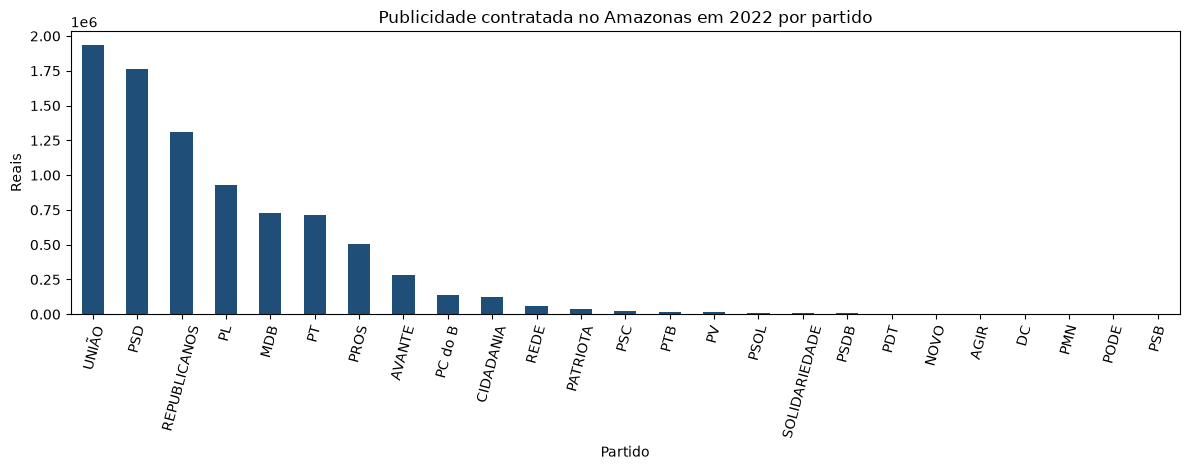

In [7]:
publicidade_2022 = carregar_gastos_publicidade(2022, candidatos_2022, uf=UF)
print(publicidade_2022.texto)
display(tabela_reais(publicidade_2022.categorias, "valor"))
display(tabela_reais(publicidade_2022.por_partido))
grafico_barras(
    publicidade_2022.por_partido,
    "Publicidade contratada no Amazonas em 2022 por partido",
    "gasto_publicidade",
    "Reais",
)
display(
    tabela_reais(
        colunas_para_exibir(
            publicidade_2022.por_candidato,
            ["partido", "numero", "nome_urna", "nome", "resultado", "gasto_publicidade"],
        )
    )
)

## Gasto com publicidade em 2026 no Amazonas, até 28/09/2026

Entra despesa contratada com data até 28 de setembro de 2026. Lançamento sem data ou com data posterior fica de fora da soma.

O TSE recusou o download. Usando a cópia pública do Internet Archive.
Baixando prestacao_contas_candidatos_2026.zip: 100%
Download concluído: prestacao_contas_candidatos_2026.zip (21.6 MB)
Lendo despesas_contratadas_candidatos_2026_AM.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\publicidade_deputado_federal_2026_AM_2026-09-28.csv
Tabela salva em C:\Users\Luiz\Documents\analise-eleitoral\dados\processados\publicidade_categorias_2026_AM_2026-09-28.csv
Deputado federal 2026: despesas contratadas de publicidade, até 28/09/2026. Recorte: AM. Arquivo do TSE gerado em 04/09/2026. Período com despesa datada: 06/08/2026 a 03/09/2026. Lançamentos de publicidade somados: 124. Lançamentos depois do corte: 0. Lançamentos sem data: 44. Coluna de classificação: DS_ORIGEM_DESPESA. Total: R$ 1.205.753,59.


,tipo,lancamentos,valor,entra_na_publicidade
0,Publicidade por materiais impressos,60,"R$ 840.225,59",sim
1,Despesa com Impulsionamento de Conteúdos,27,"R$ 305.281,00",sim
2,Publicidade por adesivos,36,"R$ 60.150,00",sim
3,Serviços advocatícios,3,"R$ 59.863,00",não
4,Comícios,1,"R$ 57.600,00",não
5,Locação/cessão de bens imóveis,2,"R$ 45.000,00",não
6,Serviços contábeis,3,"R$ 40.600,00",não
7,Água,6,"R$ 37.821,16",não
8,Diversas a especificar,7,"R$ 36.789,52",não
9,Despesas com pessoal,8,"R$ 23.200,00",não


,partido,candidatos,gasto_publicidade
0,UNIÃO,7,"R$ 708.710,00"
1,REPUBLICANOS,9,"R$ 200.695,00"
2,PL,9,"R$ 152.846,00"
3,MDB,9,"R$ 90.000,00"
4,PSD,9,"R$ 33.000,00"
5,AVANTE,9,"R$ 16.399,00"
6,MISSÃO,9,"R$ 3.403,59"
7,PSOL,5,"R$ 700,00"
8,DC,9,"R$ 0,00"
9,MOBILIZA,2,"R$ 0,00"


,partido,numero,nome_urna,nome,gasto_publicidade
0,UNIÃO,4477,FAUSTO JR,FAUSTO VIEIRA DOS SANTOS JUNIOR,"R$ 523.500,00"
1,REPUBLICANOS,1000,AMOM MANDEL,AMOM MANDEL LINS FILHO,"R$ 200.695,00"
2,PL,2233,CORONEL ROSSES,UBIRAJARA ROSSES DO NASCIMENTO JUNIOR,"R$ 100.000,00"
3,UNIÃO,4433,SAIMON BESSA,SIMON DE SOUZA GUIMARAES BESSA,"R$ 80.550,00"
4,UNIÃO,4455,DR. MIGUEL CARRATTE,MIGUEL CARRATTE NETO,"R$ 64.700,00"
5,MDB,1555,SAULLO VIANNA,SAULLO VELAME VIANNA,"R$ 60.000,00"
6,PL,2255,DELEGADO PABLO,PABLO OLIVA SOUZA,"R$ 45.381,00"
7,UNIÃO,4411,PROFESSORA THEREZINHA RUIZ,THEREZINHA RUIZ DE OLIVEIRA,"R$ 39.960,00"
8,PSD,5555,SIDNEY LEITE,SIDNEY RICARDO DE OLIVEIRA LEITE,"R$ 33.000,00"
9,MDB,1500,JESUS ALVES,JESUS ALVES DOS SANTOS,"R$ 30.000,00"


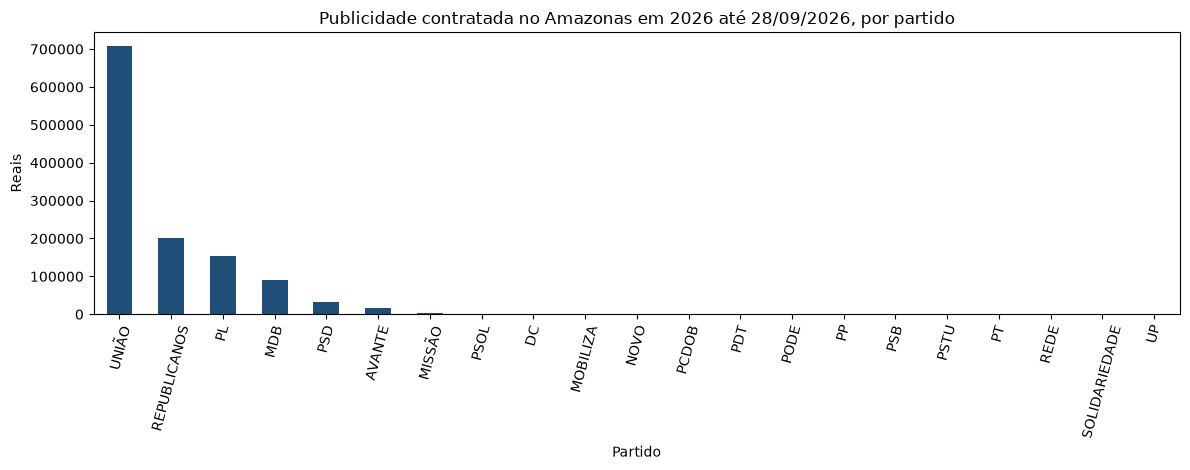

In [8]:
publicidade_2026 = carregar_gastos_publicidade(2026, candidatos_2026, data_corte=DATA_CORTE_2026, uf=UF)
print(publicidade_2026.texto)
display(tabela_reais(publicidade_2026.categorias, "valor"))
display(tabela_reais(publicidade_2026.por_partido))
grafico_barras(
    publicidade_2026.por_partido,
    "Publicidade contratada no Amazonas em 2026 até 28/09/2026, por partido",
    "gasto_publicidade",
    "Reais",
)
display(
    tabela_reais(
        colunas_para_exibir(
            publicidade_2026.por_candidato,
            ["partido", "numero", "nome_urna", "nome", "gasto_publicidade"],
        )
    )
)